<a href="https://colab.research.google.com/github/rafahcs/Projeto_AF/blob/main/projetoaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. INTRODUÇÃO


* O problema consiste em um autômato finito determinístico(AFD) que reconheça a linguagaem formada pelas notações dos elementos pertencentes aos conjuntos dos números inteiros, números reais, números hexadecimais, números em notação científica e números complexos.

* O AFD recebe uma fita de tamanho variável. Cada estado armazena o último símbolo anterior lido após a transição do estado antecesssor.

* Uma palavra só é aceita se o útimo símbolo for lido por um estado que seja final. Palavras não aceitas são rejeitadas e o autômato libera o armazenamento da fita e lê a próxima palavra.

* Se o "valor" de uma expressão regular(ER) é uma linguagem, Então as linguagem dos inteiros($L_{int}$), linguagem dos reais($L_{real}$), linguagem de notação científica($L_{cient}$), linguagem dos hexadecimais($L_{hex}$) e linguagem dos complexos($L_{comp}$) podem ser escritas como ER's. A união dessas ER's forma a linguagem do AFD A. Dessa forma, a linguagem escolhida é L(A) = $L_{int}$ ∪ $L_{real}$ ∪ $L_{cient}$ ∪ $L_{hex}$ ∪ $L_{comp}$.

  ' | ' → pipe utilizado como operador 'ou' em na expressão regular "(+ou-)", pois '+' é um símbolo nas linguagens

  $L_{int}$ = (+ | -)Σ$^{*}$ , onde Σ = {0,1,2,3,4,5,6,7,8,9}
  
  $L_{real}$ = (+ | -)Σ$^{*}$ . Σ +

  $L_{cient}$ = $L_{real}(e + E)(+ | -)Σ$^{*}$ +

  $L_{hex}$ = $[0(x + X)Σ +] + [$\#$Σ +] + [Σ +(h + H)]$, onde Σ = [0,9] ∪ [A,F] ∪ [a, f]

  $L_{comp}$ = $[L_{real}(+ | -)L_{real} i ] + (L_{real})$

  L(A) = { w | w é uma palavra real ou inteira ou complexa ou notação científica ou hexadecimal}

* A estratégia adotada foi a de execução da fita por cada autômato representado por uma função builder_ que percorre a fita lendo cada símbolo e comparando com o valor esperado para o alfabeto do autômato. Ao final são rodados os testes unitários que retornam se a fita tem uma palavra aceita ou não na linguagem.


# 2. DEFINIÇÃO FORMAL DO AUTÔMATO FINITO


A = (Q, Σ, δ, qO, F)

Q: Um conjunto finito de estados.

Σ: Um alfabeto finito de símbolos (alfabeto da fita).

δ: Função de transição

qO: Estado inicial

F: Conjunto de estados finais ou de aceitação

* Q = $Q_0 ∪ Q_{int} ∪ Q_{real} ∪ Q_{cient} ∪ Q_{hex} ∪ Q_{comp} ∪ Q_{sign} ∪ Q_{zero}$

    =  {$ q_{inicio}$ } ∪ {$ q_{int} $} ∪ {$ q_{frac}, q_{dot}, q_{dot_{start}} $} ∪ {$ q_{exp}, q_{exp_{sign}}, q_{exp_{sign}} $} ∪ {$ q_{hex_{start}}, q_{hex_{prefix}}, q_{hex_{body}}, q_{hex_{start}} $} ∪ {$ q_{complex_{sign}}, q_{complex_{dot}}, q_{complex_{frac}}, q_{complex} $} ∪ {$q_{zero}$} ∪ {$q_{sign}$}

    = {$ q_{inicio}, q_{int}, q_{frac}, q_{dot}, q_{dot_{start}}, q_{exp}, q_{exp_{sign}}, q_{hex_{start}}, q_{hex_{prefix}}, q_{hex_{body}}, q_{complex_{sign}}, q_{complex_{dot}},  q_{complex_{frac}},  q_{complex}, q_{zero}, q_{sign} $}

* Σ = {+, -, .} ∪ $\mathbb{Z}$ ∪ $\mathbb{R}$ ∪ {A-F,H,a-f,h} ∪ $\mathbb{C}$

* δ = Q x Σ $\rightarrow$ Q

* q0 = ${q_{inicio}}$

* F = $ F_{inicio} ∪ F_{sign} ∪ F_{zero} ∪ F_{int} ∪ F_{real} ∪ F_{cient} ∪ F_{hex} ∪ F_{comp}$

    = {$q_{int}$} ∪ {$ q_{int}, q_{dot}, q_{imag}, q_{hex_{end}} $} ∪ {$q_{int}$} ∪ {$ q_{int}, q_{dot}, q_{imag}, q_{hex_{end}}, q_{hex_{body}} $} ∪ {$ q_{frac}, q_{imag} $} ∪ {$ q_{exp_{num}} $} ∪ {$ q_{hex_{end}}, q_{hex_{body}} $} ∪ {$q_{imag}$}
    
    = {$ q_{int}, q_{dot}, q_{imag}, q_{hex_{end}}, q_{hex_{body}}, q_{frac}, q_{exp_{num}} $}

5-upla completa:

A = {
      ${ q_{inicio}, q_{int}, q_{frac}, q_{dot}, q_{dot_{start}}, q_{exp}, q_{exp_{sign}}, q_{hex_{start}}, q_{hex_{prefix}}, q_{hex_{body}}, q_{complex_{sign}}, q_{complex_{dot}},  q_{complex_{frac}},  q_{complex}, q_{zero}, q_{sign} }$,
      $\mathbb{Z}$ ∪ $\mathbb{R}$ ∪ {+, -, ., #, A,B,C,D,E,F,H,a,b,c,d,e,f,h} ∪ $\mathbb{C}$,
      δ,
      ${q_{inicio}}, q_{int}, q_{dot}, q_{imag}, q_{hex_{end}}, q_{hex_{body}}, q_{frac}, q_{exp_{num}}$
    }

# 3. IMPLEMENTAÇÃO


In [43]:
class AutomatoFinito:

    def __init__(self, entrada: str):
        self.entrada = entrada
        self.estado = "q_inicio"
        self.pos = 0
        self.tem_hex_letra = False
        self.hex_valido = False

    def classificar(self, c: str):
        if c == "0":
            return "ZERO"
        if c in "123456789":
            return "n"
        if c in "+-":
            return "SIGN"
        if c in "eE":
            return "EXP"
        if c in "abcdefABCDEF":
            return "l"
        if c in ".#ixXh":
            return c
        return None

    delta = {

        # início
        ("q_inicio", "SIGN"): "q_sign",
        ("q_inicio", "ZERO"): "q_zero",
        ("q_inicio", "n"): "q_int",
        ("q_inicio", "."): "q_dot_start",
        ("q_inicio", "#"): "q_hex_start",
        ("q_inicio", "i"): "q_imag",

        # sinal
        ("q_sign", "ZERO"): "q_zero",
        ("q_sign", "n"): "q_int",
        ("q_sign", "."): "q_dot_start",
        ("q_sign", "i"): "q_imag",

        # inteiro
        ("q_int", "n"): "q_int",
        ("q_int", "ZERO"): "q_int",
        ("q_int", "."): "q_dot",
        ("q_int", "EXP"): "q_exp",
        ("q_int", "SIGN"): "q_complex_sign",
        ("q_int", "i"): "q_imag",
        ("q_int", "h"): "q_hex_end",
        ("q_int", "l"): "q_hex_body",

        # zero
        ("q_zero", "n"): "q_int",
        ("q_zero", "."): "q_dot",
        ("q_zero", "EXP"): "q_exp",
        ("q_zero", "x"): "q_hex_prefix",
        ("q_zero", "X"): "q_hex_prefix",
        ("q_zero", "SIGN"): "q_complex_sign",
        ("q_zero", "i"): "q_imag",
        ("q_zero", "h"): "q_hex_end",

        # real
        ("q_dot_start", "n"): "q_frac",
        ("q_dot", "n"): "q_frac",
        ("q_dot", "EXP"): "q_exp",
        ("q_dot", "SIGN"): "q_complex_sign",
        ("q_dot", "i"): "q_imag",
        ("q_dot", "ZERO"): "q_frac",

        ("q_frac", "n"): "q_frac",
        ("q_frac", "EXP"): "q_exp",
        ("q_frac", "SIGN"): "q_complex_sign",
        ("q_frac", "i"): "q_imag",

        # científico
        ("q_exp", "SIGN"): "q_exp_sign",
        ("q_exp", "n"): "q_exp_num",
        ("q_exp", "ZERO"): "q_exp_num",
        ("q_exp_sign", "n"): "q_exp_num",
        ("q_exp_num", "ZERO"): "q_exp_num",

        # hexadecimal
        ("q_hex_start", "n"): "q_hex_body",
        ("q_hex_start", "l"): "q_hex_body",

        ("q_hex_prefix", "n"): "q_hex_body",
        ("q_hex_prefix", "l"): "q_hex_body",

        ("q_hex_body", "n"): "q_hex_body",
        ("q_hex_body", "l"): "q_hex_body",
        ("q_hex_body", "EXP"): "q_hex_body",
        ("q_hex_body", "h"): "q_hex_end",

        # complexo
        ("q_complex_sign", "n"): "q_complex",
        ("q_complex_sign", "."): "q_complex_dot",

        ("q_complex", "n"): "q_complex",
        ("q_complex", "."): "q_complex_dot",
        ("q_complex", "i"): "q_imag",

        ("q_complex_dot", "n"): "q_complex_frac",
        ("q_complex_dot", "i"): "q_imag",

        ("q_complex_frac", "n"): "q_complex_frac",
        ("q_complex_frac", "i"): "q_imag",
    }

    finais = {
        "q_int",
        "q_dot",
        "q_frac",
        "q_exp_num",
        "q_hex_body",
        "q_hex_end",
        "q_imag",
    }

    def executar(self):
      while self.pos < len(self.entrada):
          # pega o caractere atual
          c = self.entrada[self.pos]

          # classifica o símbolo
          tipo = self.classificar(c)

          # símbolo inválido → rejeita
          if tipo is None:
              return False

          # detectar letra hexadecimal (A-F)
          if tipo == "l":
              self.tem_hex_letra = True

          # cria chave (estado atual, tipo)
          chave = (self.estado, tipo)

          # se não houver transição → rejeita
          if chave not in self.delta:
              return False

          # atualiza o estado
          self.estado = self.delta[chave]

          # detectar prefixo hexadecimal válido (# ou 0x)
          if self.estado in ["q_hex_start", "q_hex_prefix"]:
              self.hex_valido = True

          # detectar sufixo hexadecimal (h)
          if tipo == "h":
              self.hex_valido = True

          # avança para o próximo caractere
          self.pos += 1

      # regra especial: evitar "AB" sem prefixo/sufixo
      if self.estado == "q_hex_body" and self.tem_hex_letra and not self.hex_valido:
          return False

      # verifica se terminou em estado final
      return self.estado in self.finais


# TESTE
if __name__ == "__main__":
    testes = [
        # INTEIRO
        "1", "-4", "+7",         # óbvias/Pequenas
        " ", "+", "-",           # Malformadas
        "13c", "++10", "-12ba",  # Inválidas
        # REAL
        "3.14", ".5", "5.", "+2.0", "-2.0", # óbvias/Pequenas
        "1.2.3", "+-0.5", ".",              # Malformadas
        "1,5", "e.5",                       # Inválidas
        # CIENTÍFICA
        "1.2e3", "-5E-10", "-5e-10", "1e0", # óbvias
        "2.e-2", ".5e3",                    # Pequenas
        "e10", "1e", "1e+-2",               # Malformadas
        "1.5e3.2", "2 e 2",                 #  Inválidas
        # HEXADECIMAL
        "0xF", "#1",              # óbvia aceita
        "Fh", "AB",               # óbvia não aceita
        "0x", "#", "h",           # Malformadas
        "0xG1", "#ZZ", "1A3Xh",   # Inválidas
        # COMPLEXO
        "i", "+i", "-i",             # óbvias
        "3+4i", "3-4i", "2.5-1.3i",  # Pequenas
        "2--i", "i+3",  "6+4j",      # Malformadas
        "2.5.3i", "2.5.3+i", "+-i",  #  Inválidas
    ]

    for t in testes:
        aut = AutomatoFinito(t)
        if(aut.executar() == True):
          print(f"{t:10} -> Resultado: {aut.executar()}\t Esperado: {aut.executar()} \t Aceita {t}")
        else:
          print(f"{t:10} -> Resultado: {aut.executar()}\t Esperado: {aut.executar()}\t Rejeita {t}")

1          -> Resultado: True	 Esperado: True 	 Aceita 1
-4         -> Resultado: True	 Esperado: True 	 Aceita -4
+7         -> Resultado: True	 Esperado: True 	 Aceita +7
           -> Resultado: False	 Esperado: False	 Rejeita  
+          -> Resultado: False	 Esperado: False	 Rejeita +
-          -> Resultado: False	 Esperado: False	 Rejeita -
13c        -> Resultado: False	 Esperado: False	 Rejeita 13c
++10       -> Resultado: False	 Esperado: False	 Rejeita ++10
-12ba      -> Resultado: False	 Esperado: False	 Rejeita -12ba
3.14       -> Resultado: True	 Esperado: True 	 Aceita 3.14
.5         -> Resultado: True	 Esperado: True 	 Aceita .5
5.         -> Resultado: True	 Esperado: True 	 Aceita 5.
+2.0       -> Resultado: True	 Esperado: True 	 Aceita +2.0
-2.0       -> Resultado: True	 Esperado: True 	 Aceita -2.0
1.2.3      -> Resultado: False	 Esperado: False	 Rejeita 1.2.3
+-0.5      -> Resultado: False	 Esperado: False	 Rejeita +-0.5
.          -> Resultado: False	 Esperado: 

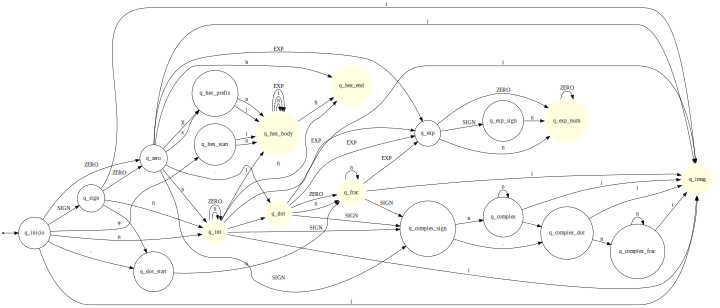

In [44]:
import graphviz
from IPython.display import display

# ____________________
#
# Diagrama de Estados
# ____________________

def desenhar_automato(delta, finais):
    # criação do grafo direcionado (Digraph)
    dot = graphviz.Digraph(comment='Autômato Finito - Números', format='png')
    dot.attr(rankdir='LR', size='10,8') # Desenha da esquerda para a direita

    # configura os nós de aceitação (Círculo Duplo)
    dot.attr('node', shape='doublecircle', style='filled', color='lightyellow')
    for estado in finais:
        dot.node(estado)

    # configura os nós normais (Círculo Simples)
    dot.attr('node', shape='circle', style='solid', color='black')

    # adiciona a seta de "Início" apontando para q_inicio
    dot.node('start', shape='point')
    dot.edge('start', 'q_inicio')

    # adiciona todas as transições
    for (estado_origem, simbolo), estado_destino in delta.items():
        dot.edge(estado_origem, estado_destino, label=simbolo)

    return dot

# renderiza o gráfico usando o dicionário delta e os estados finais
grafo = desenhar_automato(AutomatoFinito.delta, AutomatoFinito.finais)
display(grafo)

# 4. TESTES

    1. Instâncias pequenas;
    2. Instâncias inválidas malformadas;
    3. Casos óbvios de aceitação/rejeição.

```
testes = [
        # INTEIRO
        "1", "-4", "+7", # óbvias/Pequenas
        " ", "+", "-",  # Malformadas
        "13c", "++10", "-12ba" # Inválidas
        # REAL
        "3.14", ".5", "5.", "+2.0", "-2.0", # óbvias/Pequenas
        "1.2.3", "+-0.5", ".",  # Malformadas
        "1,5", "e.5", # Inválidas
        # CIENTÍFICA
        "1.2e3", "-5E-10", "-5e-10", "1e0", # óbvias
        "e10", "1e", "1e+-2", # Malformadas
        "1.5e3.2", "2 e 2", #  Inválidas
        # HEXADECIMAL
        "0xF", "#1", "Fh",  # óbvias
        "0x", "#", "h", # Malformadas
        "0xG1", "#ZZ", "1A3Xh", # Inválidas
        # COMPLEXO
        "i", "+i", "-i",  # óbvias
        "3+4i", "3-4i", "2.5-1.3i", # Pequenas
        "2--i", "i+3",  "6+4j", # Malformadas
        "2.5.3i", "2.5.3+i", "+-i", #  Inválidas
    ]

```

# 5. DEMONSTRAÇÃO FORMAL

Seja A um autômato finito e L uma linguagem, onde

L = $L_{int}  ∪ L_{real} ∪ L_{cient} ∪ L_{hex} ∪ L_{comp}$.

Dizemos que A é correto em relação à L, se L = L(A), ou seja, se A reconhece L. Quando L está clara pelo contexto, podemos dizer apenas que A é correto.

Para provar a corretude de A  devemos provar que para qualquer palavra $w ∈ Σ^*$: $\hat{δ}(q0, w) ∈ F ⇔ w ∈ L$, onde $\hat{δ}$ é função de transição estendida.

## Passo 1: Caso base (n = 0)

Seja |w| = n = 0. A única palavra de tamanho zero é a palavra vazia ( ϵ ). Pela definição formal da função de transição estendida:  $\hat{δ}(q0,ϵ)=q0$

O nosso estado inicial é  $q0 = q_{inicio}$. Verificando o conjunto de estados finais  F , observamos que  $q_{inicio} ∉ F$ . Portanto, o autómato rejeita a palavra vazia. Analisando as regras da linguagem  L , sabemos que uma cadeia vazia não constitui um número válido em nenhum dos cinco formatos. Logo,  ϵ∉L . O caso base é verdadeiro:  $\hat{δ}(q0,ϵ) ∉ F ⟺ ϵ ∉ L $ .

$\hat{δ}(q_{inicio},ϵ) ∉ F ⟺ ϵ ∉ L $

## Passo 2: Hipótese de Indução (n = k)

Assumimos como verdadeira a hipótese de que, para qualquer palavra  w temos |w| = n = k, o estado alcançado  $ q = \hat{δ}(q0,w) $  reflete corretamente a estrutura sintática do prefixo consumido até ao momento.

Isso implica as seguintes condições sob a hipótese:

1. Se  w  já constitui um número válido de  L  (ex: 4123), então  $q ∈ F$  (neste caso,  $q_{int}$ ).

2. Se  w  é um prefixo incompleto mas válido de  L  (ex: 2e), então  $q ∈ Q$  mas $q ∉ F$ (neste caso,  $q_{exp}$ ).

3. Se  w  contém uma palavra inválida (ex: ++), o autómato atingiu o estado de erro ( ∅ ) e rejeitou a cadeia.
  

## Passo Indutivo (n = k + 1)
  Consideremos uma nova palavra  x = wa , onde  |w| = k e $a ∈ Σ$ . O tamanho de  x  é  k+1 . A função de transição estendida diz-nos que:  $\hat{δ}(q0,wa)=δ(\hat{δ}(q0,w),a)=δ(q,a) $

Precisamos de provar que a leitura do novo símbolo  a  a partir do estado  q  mantém a corretude do autómato. Vamos dividir a prova em 3 casos de transição possíveis para  δ(q,a) :

**Caso 1: Transição de Fecho (De válido para válido)**

* Seja  w = "42"  (onde $ w ∈ L_{int} $ e $ q = q_{int} ∈ F $).

* Se  a = "5" , $ δ(q_{int}, dg) = q_{int} ∈ F $.

* O novo x é "425", que continua a pertencer a  $L_{int}$ . A aceitação mantém-se correta.

**Caso B: Resolução de Incompletude (De inválido para válido)**

* Seja  w = "−5e"  (um prefixo científico incompleto, logo $ w ∉ L$ ). Pela hipótese indutiva, $ q = q_{exp} ∉ F $.
* Se o próximo símbolo for  a = "2" , consultamos a tabela de transição: $ δ(q_{exp},dg) = q_{exp_{num}} ∈ F $.
* A nova cadeia  x  é "-5e2", que é um número científico perfeitamente formado.
Como $ x ∈ L_{cient} $ , o autómato transitou corretamente para um estado de aceitação. A propriedade verifica-se.

**Cenário C: Violação Sintática (Para o Estado Morto)**

* Seja w = "3.14" (onde $ w ∈ L_{real} $ e $ q = q_{frac} ∈ F $ ).
* Se o símbolo lido for um segundo ponto decimal  a = "." , tentamos calcular δ($q_{frac}, pt$) .

* Como esta transição não existe no mapa do nosso AFD, $ δ(q,a)=∅ $. O autómato sai de F e estaciona num estado morto.
* A nova cadeia  x = "3.14."  é malformada e não pertence a  L . A rejeição é correta.

## Conclusão da demonstração

Por meio da indução matemática, demonstramos que para qualquer cadeia de tamanho  0,k  e  k+1 , as trasições  δ  garantem que a máquina só aceita estados pertencentes a  F  se, e somente se, a linguagem  L for aceita ao longo de toda a fita.

# 6. CONCLUSÃO

## Limitações/Desafios

- Limitação do modelo AFD, que não possuem memória limitadas, ou seja,  não conseguem lidar com estruturas mais complexas que exigem “lembrar” muitas informações.

- Testes não cobrem 100% dos casos. há um número finito de casos e palavras específicas. Isso limita o AFD a não ser testado em todas as combinações de palavras possíveis.

- Sensibilidade a Espaços e Caracteres Invisíveis: O autômato falha se a fita contiver espaços no início ou no fim (ex: " 123 "), pois ele tenta processar o espaço como um símbolo e não encontra transição na função delta.

- O autômato realiza apenas uma decisão final binária:
aceitar ou rejeitar a cadeia de entrada, ou seja, não temos outras informações como qual tipo de número foi reconhecido ou qual ponto o erro ocorreu.


## Aprendizados

- Compreensão do funcionamento de um AFD
- Importância de tratar casos de erro e entradas inválidas
- Modelagem com diagramas facilita a compreensão do problema.
